<h1 style="font-size: 1.6rem; font-weight: bold">ITO 5221: Intelligent Image and Video Analysis</h1>
<h1 style="font-size: 1.6rem; font-weight: bold">Module 2: Feature Extraction</h1>
<p style="margin-top: 5px; margin-bottom: 5px;">Monash University Australia</p>
<p style="margin-top: 5px; margin-bottom: 5px;">Jupyter Notebook by: Tristan Sim Yook Min</p>
References: Information Source from Monash Faculty of Information Technology

---

## **Feature**

To understand what a "feature" means, consider the **Kaniza Triangle** a well-known optical illusion that reveals how our visual systems work.

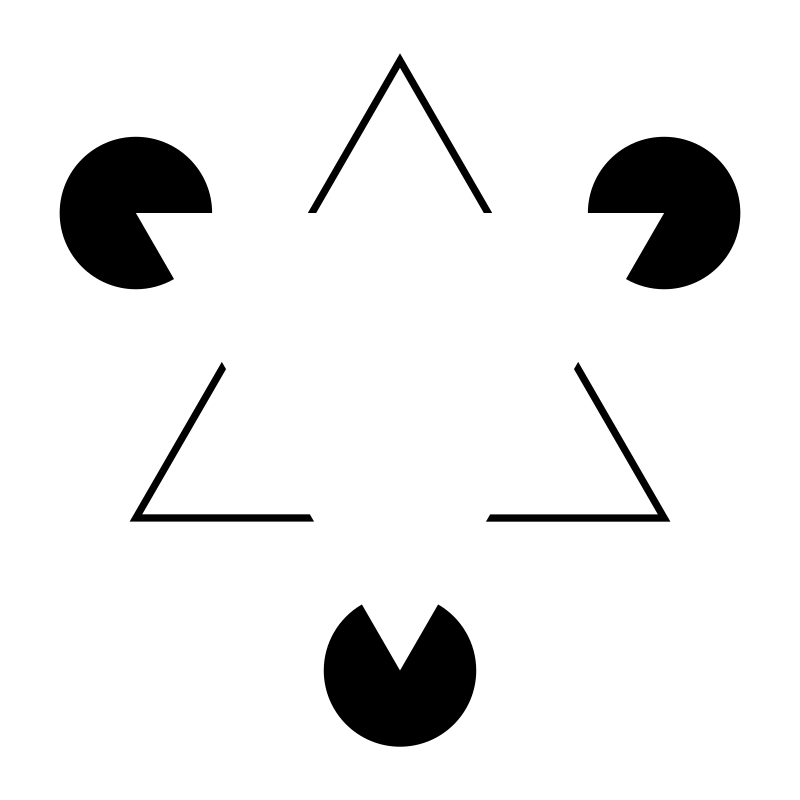

*Kanizsa triangle (2007) <https://bit.ly/3LPm7ES>*

Looking at the figure, most people perceive:
- A bright, upright triangle in the foreground
- Disc shapes tucked beneath its corners
- A second, inverted triangle outlined in black

But here's the catch, **no complete triangles actually exist in the image.** The spatially separated fragments trick our brain into filling in the gaps, creating what are known as **illusory contours**. This phenomenon is called **modal completion**.

#### **So how does this relate to features?**

Just like our brain infers triangles from edges and partial shapes, a model identifies objects by picking up on measurable visual cues: edges, contours, colour gradients, textures, and so on. A **feature** is simply a piece of information extracted from the content of an image or video that helps describe or identify what's in it.

#### **Two Levels of Feature Perception**

This statistics-based perception from images can be broadly divided into two levels:

| Level | What it captures | Example |
|---|---|---|
| **Holistic** | The overall scene or global structure | "This looks like a beach" |
| **Local/Regional** | Object-specific and scene-specific attributes | "There is a red umbrella in the corner" |

***
## **Interest Point**

### **Matching Criteria**

To determine whether a region in an image is interesting (e.g., a corner), we slide a small window across the image and measure how much the content changes when we shift it.

The window $w$ is moved by a shift $(u, v)$, and we compute the **sum of squared differences** between the original patch and the shifted patch:

$$E(u, v) = \sum_{x,y} w(x, y) \left[ I(x+u, y+v) - I(x, y) \right]^2$$

Where:
- $I(x, y)$ = the pixel intensity at position $(x, y)$ in the original image
- $I(x+u, y+v)$ = the pixel intensity after shifting the window by $(u, v)$
- $w(x, y)$ = the **window function** — determines how much each pixel in the patch contributes
- $E(u, v)$ = the **error surface** — tells us how much the patch changed after the shift

#### **Window function choices**
The window function $w(x, y)$ can take two common forms:
- **Flat window** — value is 1 inside the window and 0 outside (equal weighting)
- **Gaussian window** — smoothly weights pixels, giving more importance to the centre

<br>

### **Corner Detection: Mathematics**

#### **Step 1: Taylor Expansion Approximation**

For small shifts $(u, v)$, we can approximate the shifted intensity using a first-order Taylor expansion:

$$I(x+u, y+v) \approx I(x, y) + u \cdot \frac{\partial I}{\partial x}(x, y) + v \cdot \frac{\partial I}{\partial y}(x, y)$$

This replaces the shifted pixel value with the original value plus a correction based on the **image gradients** (how fast intensity changes in the $x$ and $y$ directions).

#### **Step 2: Substituting into $E(u,v)$**

Plugging the approximation back into the error formula:

$$E(u,v) = \sum_{x,y} w(x,y) \Big[ I(x+u, y+v) - I(x,y) \Big]^2$$

$$\approx \sum_{x,y} w(x,y) \Big[ u \cdot I_x + v \cdot I_y \Big]^2$$

where $I_x = \frac{\partial I}{\partial x}$ and $I_y = \frac{\partial I}{\partial y}$ are shorthand for the partial derivatives.

#### **Step 3: Expanding the square**

$$= \sum_{x,y} w(x,y) \Big( u^2 I_x^2 + 2uv \cdot I_x I_y + v^2 I_y^2 \Big)$$

#### **Step 4: Matrix form**

This can be rewritten compactly as a quadratic form:

$$E(u,v) \approx \begin{bmatrix} u & v \end{bmatrix} \left( \sum_{x,y} w(x,y) \begin{bmatrix} I_x^2 & I_x I_y \\ I_x I_y & I_y^2 \end{bmatrix} \right) \begin{bmatrix} u \\ v \end{bmatrix}$$

We define the **structure matrix** (or second moment matrix) $M$ as:

$$M = \sum_{x,y} w(x,y) \begin{bmatrix} I_x^2 & I_x I_y \\ I_x I_y & I_y^2 \end{bmatrix}$$

So the error simplifies to:

$$E(u,v) \approx \begin{bmatrix} u & v \end{bmatrix} M \begin{bmatrix} u \\ v \end{bmatrix}$$

$M$ is a $2 \times 2$ moment matrix computed from image gradients.

<br>

### **Harris Detector**

$E(u,v)$ describes an **ellipse** in the $(u,v)$ space, where $M$ acts as the covariance matrix.

Since $M$ is symmetric, we can diagonalise it:

$$M = V \begin{bmatrix} \lambda_1 & 0 \\ 0 & \lambda_2 \end{bmatrix} V^{-1}$$

where $\lambda_1$ and $\lambda_2$ are the **eigenvalues** of $M$.

- The eigenvector for $\lambda_{\max}$ points in the **direction of fastest intensity change**
- The eigenvector for $\lambda_{\min}$ points in the **direction of slowest intensity change**
- The semi-axes of the ellipse have lengths $(\lambda_{\max})^{-1/2}$ and $(\lambda_{\min})^{-1/2}$

#### **Classifying image points using eigenvalues of $M$**

| Condition | Region Type | Interpretation |
|---|---|---|
| $\lambda_1$ and $\lambda_2$ are both small | **Flat region** | $E$ is nearly constant in all directions — no texture |
| $\lambda_1 \gg \lambda_2$ or $\lambda_2 \gg \lambda_1$ | **Edge** | $E$ increases in only one direction |
| $\lambda_1$ and $\lambda_2$ are both large, $\lambda_1 \sim \lambda_2$ | **Corner** | $E$ increases in all directions |

<br>

### **Harris Interest Point: Steps**

1. Compute image gradients in $x$ and $y$ (i.e. $I_x$ and $I_y$)
2. Compute the gradient products: $I_x^2$, $I_y^2$, and $I_x \cdot I_y$
3. Apply **Gaussian blur** to each of the gradient product images (this is the window function $w$)
4. Compute the **Harris response** for each pixel: $R = \det(M) - \alpha \cdot (\text{trace}(M))^2$
5. Select points where $R$ is above a chosen **threshold**
6. Apply **Non-maximal suppression** — keep only local maxima to avoid clustered detections

<br>

### **Fitting an Elliptical Disk**

#### **Second Moments for a Region**

From the structure matrix $M$, we define three components computed over a window $W$ centred at a pixel:

$$a = \sum_{i \in W} I_{x_i}^2 \qquad b = 2\sum_{i \in W} I_{x_i} I_{y_i} \qquad c = \sum_{i \in W} I_{y_i}^2$$

These are the entries of the $2 \times 2$ matrix $M = \begin{bmatrix} a & b/2 \\ b/2 & c \end{bmatrix}$, which captures how the gradient vectors are distributed within the window.

#### **Ellipse Axes Lengths (Eigenvalues)**

The eigenvalues of $M$ give us the lengths of the axes of the fitted ellipse:

$$\lambda_1 = E_{max} = \frac{1}{2} \left[ a + c + \sqrt{b^2 + (a - c)^2} \right]$$

$$\lambda_2 = E_{min} = \frac{1}{2} \left[ a + c - \sqrt{b^2 + (a - c)^2} \right]$$

- $\lambda_1$ corresponds to the direction of **fastest intensity change**
- $\lambda_2$ corresponds to the direction of **slowest intensity change**

<br>

### **Interpretation of $\lambda_1$ and $\lambda_2$**

The shape of the fitted ellipse tells us what kind of region we are looking at:

| Region Type | Ellipse Shape | $\lambda_1$ vs $\lambda_2$ | Gradient Distribution |
|---|---|---|---|
| **Flat** | Tiny circle (clustered near origin) | $\lambda_1 \sim \lambda_2$, both small | Gradients are weak in all directions |
| **Edge** | Elongated ellipse | $\lambda_1 \gg \lambda_2$ (one large, one small) | Gradients are strong in one direction only |
| **Corner** | Large circle | $\lambda_1 \sim \lambda_2$, both large | Gradients are strong and spread in all directions |

#### **Intuition**
- **Flat region** — the gradient scatter plot is a small blob near the origin. Both eigenvalues are small, meaning intensity barely changes no matter which direction you shift the window.
- **Edge region** — the gradients line up along one direction, forming a stretched ellipse. One eigenvalue is large (change across the edge) and the other is small (change along the edge).
- **Corner region** — the gradients point in many directions, forming a large, roughly circular spread. Both eigenvalues are large, meaning shifting the window in *any* direction causes significant change — this is exactly what makes corners distinctive and useful as interest points.

*** 